In [1]:
%run nb1_setup.ipynb

# Notebook 2: Primary Analysis

## Per-Repeat Human vs LLM Comparison

Each model was queried **4 independent times** (repeats 0-3). Within each repeat the model answered every route **4 times** (reruns); majority-vote consensus is the model's prediction - identical to human presence-vote majority.

This gives **one MCC per model per repeat** (4 independent observations). Comparison is symmetric:
- **Humans:** consensus from ~2-4 expert votes (fixed ground truth)
- **LLMs:** consensus from 4 reruns within one repeat

**Uncertainty quantification:** Mean MCC +/- SD, 95% bootstrap CI, exact pairwise permutation test (C(8,4)=70, min p=0.014)

In [2]:
import os
os.makedirs("results", exist_ok=True)
for _r in range(4):
    os.makedirs(f"repeat_{_r}", exist_ok=True)

import numpy as np
import pandas as pd
from sklearn.metrics import matthews_corrcoef
from itertools import combinations

CSV = "expert_feedback_combined_new_llms.csv"
LLM_IDENTIFIERS = ["Claude Opus 4.8", "Gemini 3.1 Pro", "GPT-5.5", "Llama 3.1 70B"]
N_BOOTSTRAP = 10_000
RNG_SEED = 42

df = pd.read_csv(CSV)

# Human rows: no feedback_type; reaction feedback lives in local_feedback
# LLM rows:  feedback_type == "reaction" for reaction-level rows
human_mask = ~df["source_file"].isin(LLM_IDENTIFIERS)
human_df   = df[human_mask & df["local_feedback"].notna() & df["reaction_hash"].notna()].copy()
llm_df     = df[~human_mask & (df["feedback_type"] == "reaction")].copy()

# ── Human ground truth: one consensus label per reaction ──────────────────────
# Built once from all human votes — this is fixed ground truth, not repeated.
human_labels = {}
group_analyzer_rxn = GroupConsensusAnalyzer("reaction_hash")
for rxn_hash, grp in human_df.groupby("reaction_hash"):
    res = group_analyzer_rxn.get_group_consensus(
        grp, "source_file", "local_feedback", "local_feedback_text"
    )
    sent = res["dominant_sentiment"]
    if sent in ("Positive", "Negative"):
        human_labels[rxn_hash] = 1 if sent == "Positive" else 0

print(f"Reactions with human consensus label: {len(human_labels)}")

# ── Per-repeat MCC: one independent trial per repeat ─────────────────────────
# Within each repeat, the 4 reruns are resolved by majority vote via
# GroupConsensusAnalyzer — exactly as human votes are resolved.
def get_llm_predictions(llm_name, repeat, llm_df, human_labels, group_analyzer):
    """Return (y_true, y_pred, hashes) and MCC for one LLM on one repeat."""
    sub = llm_df[(llm_df["source_file"] == llm_name) & (llm_df["repeat"] == repeat)]
    y_true, y_pred, hashes = [], [], []
    for rxn_hash, grp in sub.groupby("reaction_hash"):
        if rxn_hash not in human_labels:
            continue
        res = group_analyzer.get_group_consensus(
            grp, "source_file", "local_feedback", "local_feedback_text"
        )
        sent = res["dominant_sentiment"]
        if sent not in ("Positive", "Negative"):
            continue
        y_true.append(human_labels[rxn_hash])
        y_pred.append(1 if sent == "Positive" else 0)
        hashes.append(rxn_hash)
    mcc = (matthews_corrcoef(y_true, y_pred)
           if len(set(y_true)) >= 2 and len(set(y_pred)) >= 2 else np.nan)
    return y_true, y_pred, hashes, mcc

repeats = sorted(llm_df["repeat"].dropna().unique().astype(int))
print(f"Repeats found: {repeats}")

mcc_per_repeat = {}
preds_per_repeat = {}   # {llm: {repeat: (y_true, y_pred, hashes)}} — used by kappa + calibration cells
for llm in LLM_IDENTIFIERS:
    mccs = []
    preds_per_repeat[llm] = {}
    for r in repeats:
        yt, yp, hsh, m = get_llm_predictions(llm, r, llm_df, human_labels, group_analyzer_rxn)
        preds_per_repeat[llm][r] = (yt, yp, hsh)
        mccs.append(m)
        print(f"  {llm}  repeat={r}:  MCC = {m:.4f}" if not np.isnan(m)
              else f"  {llm}  repeat={r}:  MCC = NaN")
    mcc_per_repeat[llm] = mccs

# ── Bootstrap 95 % CI on the mean of 4 repeat MCCs ───────────────────────────
rng = np.random.default_rng(RNG_SEED)

def bootstrap_ci(values, n_boot=N_BOOTSTRAP, ci=0.95, rng=rng):
    values = np.array([v for v in values if not np.isnan(v)])
    if len(values) == 0:
        return np.nan, np.nan, np.nan
    boot_means = [rng.choice(values, size=len(values), replace=True).mean()
                  for _ in range(n_boot)]
    lo = np.percentile(boot_means, (1 - ci) / 2 * 100)
    hi = np.percentile(boot_means, (1 + ci) / 2 * 100)
    return float(np.mean(values)), float(lo), float(hi)

summary_rows = []
for llm in LLM_IDENTIFIERS:
    vals  = mcc_per_repeat[llm]
    clean = [v for v in vals if not np.isnan(v)]
    mean, lo, hi = bootstrap_ci(vals)
    row = {"Model": llm}
    for r in repeats:
        row[f"MCC_r{r}"] = round(vals[r], 4) if r < len(vals) and not np.isnan(vals[r]) else np.nan
    row.update({
        "Mean_MCC": round(mean, 4),
        "SD_MCC":   round(float(np.std(clean, ddof=1)), 4) if len(clean) > 1 else np.nan,
        "CI95_lo":  round(lo, 4),
        "CI95_hi":  round(hi, 4),
    })
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).sort_values("Mean_MCC", ascending=False)
print("\n=== Per-repeat MCC with 95 % bootstrap CI ===")
print(summary_df.to_string(index=False))
summary_df.to_csv("results/mcc_uncertainty_summary.csv", index=False)


Reactions with human consensus label: 204
Repeats found: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
  Claude Opus 4.8  repeat=0:  MCC = 0.2691
  Claude Opus 4.8  repeat=1:  MCC = 0.2228
  Claude Opus 4.8  repeat=2:  MCC = 0.2527
  Claude Opus 4.8  repeat=3:  MCC = 0.2180
  Gemini 3.1 Pro  repeat=0:  MCC = 0.3697
  Gemini 3.1 Pro  repeat=1:  MCC = 0.4732
  Gemini 3.1 Pro  repeat=2:  MCC = 0.4318
  Gemini 3.1 Pro  repeat=3:  MCC = 0.4454
  GPT-5.5  repeat=0:  MCC = 0.3454
  GPT-5.5  repeat=1:  MCC = 0.3175
  GPT-5.5  repeat=2:  MCC = 0.3546
  GPT-5.5  repeat=3:  MCC = 0.3857
  Llama 3.1 70B  repeat=0:  MCC = 0.0517
  Llama 3.1 70B  repeat=1:  MCC = -0.0212
  Llama 3.1 70B  repeat=2:  MCC = 0.0400
  Llama 3.1 70B  repeat=3:  MCC = 0.2169

=== Per-repeat MCC with 95 % bootstrap CI ===
          Model  MCC_r0  MCC_r1  MCC_r2  MCC_r3  Mean_MCC  SD_MCC  CI95_lo  CI95_hi
 Gemini 3.1 Pro  0.3697  0.4732  0.4318  0.4454    0.4300  0.0438   0.3886   0.4629
        GPT-5.5  0.3454  0.317

In [3]:
# ── Pairwise exact permutation test (H1: MCC_A > MCC_B) ──────────────────────
# With 4 repeats per model there are C(8,4) = 70 possible label assignments
# under the null → minimum achievable one-sided p-value = 1/70 ≈ 0.014.
# We enumerate all permutations exactly (no approximation needed).

from itertools import permutations as iter_perms
from math import comb

def exact_perm_test_greater(a_vals, b_vals):
    """
    Exact one-sided permutation test: H1: mean(A) > mean(B).
    Pools a_vals and b_vals, enumerates all C(2n,n) splits, counts
    how many permuted deltas are >= the observed delta (one-sided p-value for H1: A > B).
    """
    a = np.array([v for v in a_vals if not np.isnan(v)])
    b = np.array([v for v in b_vals if not np.isnan(v)])
    if len(a) == 0 or len(b) == 0:
        return np.nan
    n = len(a)
    if len(b) != n:
        return np.nan
    observed_delta = a.mean() - b.mean()
    pooled = np.concatenate([a, b])
    from itertools import combinations as iter_comb
    count_geq = 0
    total = 0
    for idx_a in iter_comb(range(2 * n), n):
        idx_b = [i for i in range(2 * n) if i not in idx_a]
        delta = pooled[list(idx_a)].mean() - pooled[idx_b].mean()
        if delta >= observed_delta:
            count_geq += 1
        total += 1
    return count_geq / total

print(f"C(8,4) = {comb(8,4)} permutations per pair  →  min p = {1/comb(8,4):.4f}")

pairs_rows = []
for llm_a, llm_b in combinations(LLM_IDENTIFIERS, 2):
    mean_a = np.nanmean(mcc_per_repeat[llm_a])
    mean_b = np.nanmean(mcc_per_repeat[llm_b])
    if mean_a < mean_b:
        llm_a, llm_b = llm_b, llm_a
        mean_a, mean_b = mean_b, mean_a
    p = exact_perm_test_greater(mcc_per_repeat[llm_a], mcc_per_repeat[llm_b])
    pairs_rows.append({
        "Model A (higher mean)": llm_a,
        "Model B":               llm_b,
        "Mean_MCC_A":            round(mean_a, 4),
        "Mean_MCC_B":            round(mean_b, 4),
        "Delta_MCC (A−B)":       round(mean_a - mean_b, 4),
        "p (one-sided, A>B)":    round(p, 4) if not np.isnan(p) else np.nan,
        "Significant (p<0.05)":  "Yes" if (not np.isnan(p) and p < 0.05) else "No",
    })

pairwise_df = pd.DataFrame(pairs_rows)
print("\n=== Pairwise exact permutation tests ===")
print(pairwise_df.to_string(index=False))
pairwise_df.to_csv("results/mcc_pairwise_significance.csv", index=False)


C(8,4) = 70 permutations per pair  →  min p = 0.0143

=== Pairwise exact permutation tests ===
Model A (higher mean)         Model B  Mean_MCC_A  Mean_MCC_B  Delta_MCC (A−B)  p (one-sided, A>B) Significant (p<0.05)
       Gemini 3.1 Pro Claude Opus 4.8      0.4300      0.2407           0.1894              0.0143                  Yes
              GPT-5.5 Claude Opus 4.8      0.3508      0.2407           0.1101              0.0143                  Yes
      Claude Opus 4.8   Llama 3.1 70B      0.2407      0.0719           0.1688              0.0143                  Yes
       Gemini 3.1 Pro         GPT-5.5      0.4300      0.3508           0.0792              0.0286                  Yes
       Gemini 3.1 Pro   Llama 3.1 70B      0.4300      0.0719           0.3582              0.0143                  Yes
              GPT-5.5   Llama 3.1 70B      0.3508      0.0719           0.2789              0.0143                  Yes


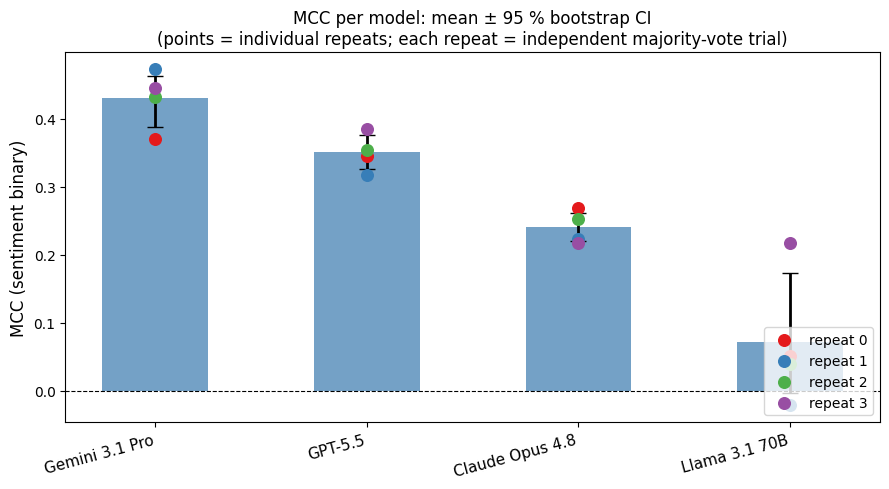

Saved mcc_uncertainty_plot.png


In [4]:
import matplotlib.pyplot as plt

# ── Plot: mean MCC ± 95 % CI with individual repeat points ───────────────────
fig, ax = plt.subplots(figsize=(9, 5))

models  = summary_df["Model"].tolist()
means   = summary_df["Mean_MCC"].tolist()
lo_errs = [m - lo for m, lo in zip(summary_df["Mean_MCC"], summary_df["CI95_lo"])]
hi_errs = [hi - m  for m, hi in zip(summary_df["Mean_MCC"], summary_df["CI95_hi"])]

x = np.arange(len(models))
ax.bar(x, means, 0.5, yerr=[lo_errs, hi_errs],
       capsize=6, color="steelblue", alpha=0.75, error_kw={"elinewidth": 2})

rep_colors = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3"]
for i, llm in enumerate(models):
    for j, r_val in enumerate(mcc_per_repeat[llm]):
        if not np.isnan(r_val):
            ax.scatter(x[i], r_val, color=rep_colors[j % 4],
                       zorder=5, s=70, label=f"repeat {j}" if i == 0 else "")

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, ha="right", fontsize=11)
ax.set_ylabel("MCC (sentiment binary)", fontsize=12)
ax.set_title(
    "MCC per model: mean ± 95 % bootstrap CI\n"
    "(points = individual repeats; each repeat = independent majority-vote trial)",
    fontsize=12)

handles, labels = ax.get_legend_handles_labels()
ax.legend(dict(zip(labels, handles)).values(),
          dict(zip(labels, handles)).keys(),
          fontsize=10, loc="lower right")

plt.tight_layout()
plt.savefig("results/mcc_uncertainty_plot.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved mcc_uncertainty_plot.png")


## Inter-LLM Agreement: Pairwise Cohen's Kappa

a pairwise kappa table between LLM majority votes across 204 reactions. Uses repeat=0 for symmetric comparison.


=== Kappa repeat=0 ===
=== Inter-LLM Cohen's kappa (repeat=0 consensus, 204 reactions) ===
                 Claude Opus 4.8  Gemini 3.1 Pro  GPT-5.5  Llama 3.1 70B
Claude Opus 4.8            1.000           0.423    0.461          0.039
Gemini 3.1 Pro             0.423           1.000    0.580         -0.007
GPT-5.5                    0.461           0.580    1.000         -0.017
Llama 3.1 70B              0.039          -0.007   -0.017          1.000


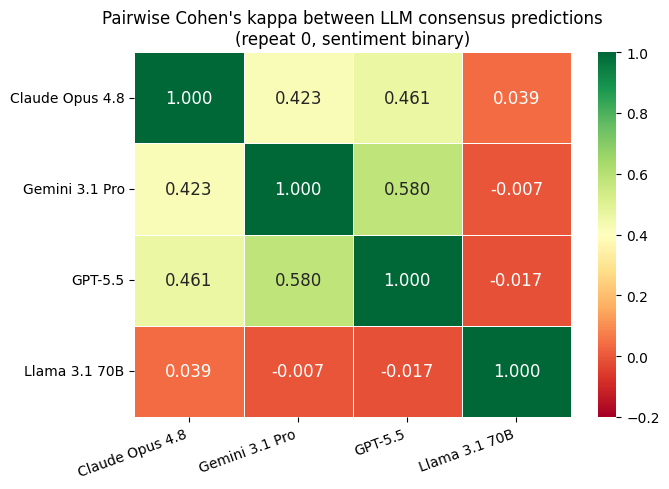

Saved inter_llm_kappa_heatmap.png and inter_llm_kappa.csv

=== Kappa repeat=1 ===
=== Inter-LLM Cohen's kappa (repeat=1 consensus, 204 reactions) ===
                 Claude Opus 4.8  Gemini 3.1 Pro  GPT-5.5  Llama 3.1 70B
Claude Opus 4.8            1.000           0.325    0.491          0.001
Gemini 3.1 Pro             0.325           1.000    0.463          0.029
GPT-5.5                    0.491           0.463    1.000         -0.006
Llama 3.1 70B              0.001           0.029   -0.006          1.000


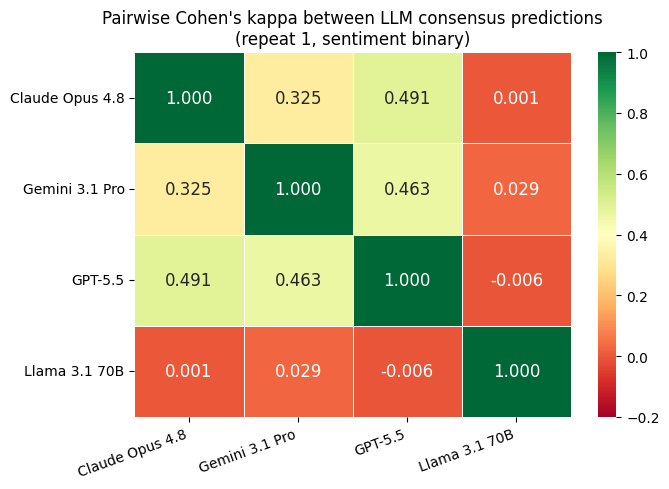

Saved inter_llm_kappa_heatmap.png and inter_llm_kappa.csv

=== Kappa repeat=2 ===
=== Inter-LLM Cohen's kappa (repeat=2 consensus, 204 reactions) ===
                 Claude Opus 4.8  Gemini 3.1 Pro  GPT-5.5  Llama 3.1 70B
Claude Opus 4.8            1.000           0.413    0.412          0.036
Gemini 3.1 Pro             0.413           1.000    0.560          0.052
GPT-5.5                    0.412           0.560    1.000          0.050
Llama 3.1 70B              0.036           0.052    0.050          1.000


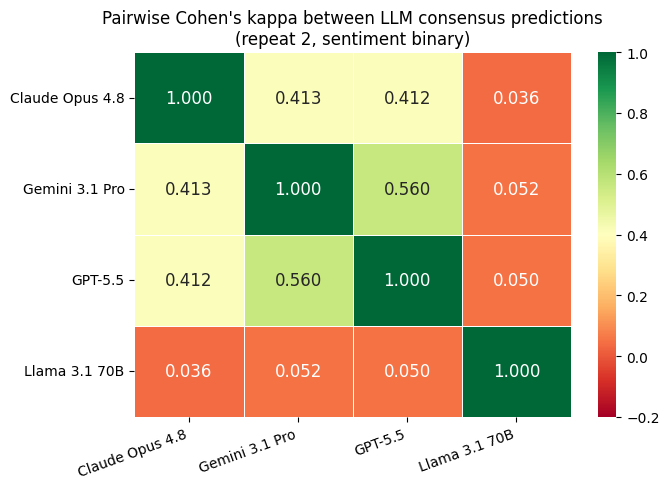

Saved inter_llm_kappa_heatmap.png and inter_llm_kappa.csv

=== Kappa repeat=3 ===
=== Inter-LLM Cohen's kappa (repeat=3 consensus, 204 reactions) ===
                 Claude Opus 4.8  Gemini 3.1 Pro  GPT-5.5  Llama 3.1 70B
Claude Opus 4.8            1.000           0.366    0.435          0.080
Gemini 3.1 Pro             0.366           1.000    0.546          0.135
GPT-5.5                    0.435           0.546    1.000          0.062
Llama 3.1 70B              0.080           0.135    0.062          1.000


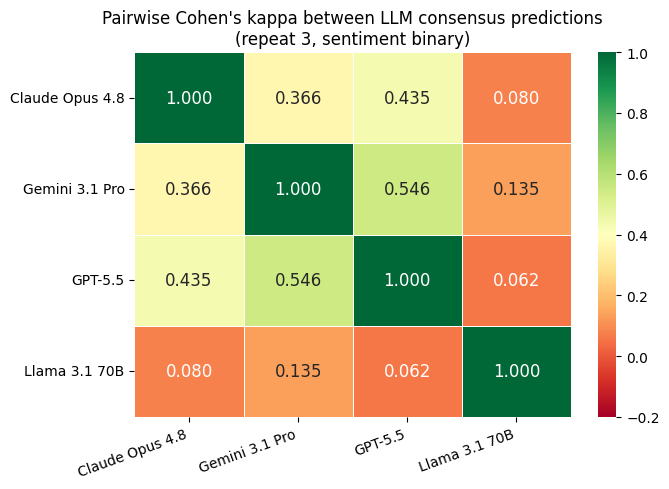

Saved inter_llm_kappa_heatmap.png and inter_llm_kappa.csv


In [17]:
# ── Inter-LLM pairwise Cohen's kappa ─────────────────────────────────────────
from sklearn.metrics import cohen_kappa_score
import seaborn as sns

for REPEAT_FOR_KAPPA in range(4):
    print(f"\n=== Kappa repeat={REPEAT_FOR_KAPPA} ===")
    os.makedirs(f"repeat_{REPEAT_FOR_KAPPA}", exist_ok=True)

    # preds_per_repeat built in cell above: {llm: {repeat: (y_true, y_pred, hashes)}}
    llm_consensus = {}
    for llm in LLM_IDENTIFIERS:
        yt, yp, hsh = preds_per_repeat[llm][REPEAT_FOR_KAPPA]
        llm_consensus[llm] = dict(zip(hsh, yp))

    kappa_matrix = pd.DataFrame(index=LLM_IDENTIFIERS, columns=LLM_IDENTIFIERS, dtype=float)
    for llm in LLM_IDENTIFIERS:
        kappa_matrix.loc[llm, llm] = 1.0

    for llm_a, llm_b in combinations(LLM_IDENTIFIERS, 2):
        common = sorted(set(llm_consensus[llm_a]) & set(llm_consensus[llm_b]))
        if len(common) < 2:
            kappa_matrix.loc[llm_a, llm_b] = float("nan")
            kappa_matrix.loc[llm_b, llm_a] = float("nan")
            continue
        ya = [llm_consensus[llm_a][h] for h in common]
        yb = [llm_consensus[llm_b][h] for h in common]
        k = (cohen_kappa_score(ya, yb)
             if len(set(ya)) > 1 and len(set(yb)) > 1 else float("nan"))
        kappa_matrix.loc[llm_a, llm_b] = round(k, 3)
        kappa_matrix.loc[llm_b, llm_a] = round(k, 3)

    print(f"=== Inter-LLM Cohen's kappa (repeat={REPEAT_FOR_KAPPA} consensus, 204 reactions) ===")
    print(kappa_matrix.to_string())
    kappa_matrix.to_csv(f"repeat_{REPEAT_FOR_KAPPA}/inter_llm_kappa.csv")

    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(kappa_matrix.astype(float), annot=True, fmt=".3f", cmap="RdYlGn",
                vmin=-0.2, vmax=1.0, linewidths=0.5, ax=ax,
                xticklabels=LLM_IDENTIFIERS, yticklabels=LLM_IDENTIFIERS,
                annot_kws={"size": 12})
    ax.set_title(f"Pairwise Cohen's kappa between LLM consensus predictions\n"
                 f"(repeat {REPEAT_FOR_KAPPA}, sentiment binary)", fontsize=12)
    plt.xticks(rotation=20, ha="right", fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    plt.tight_layout()
    plt.savefig(f"repeat_{REPEAT_FOR_KAPPA}/inter_llm_kappa_heatmap.png", dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved inter_llm_kappa_heatmap.png and inter_llm_kappa.csv")


## Inter-LLM Kappa — Averaged Across 4 Repeats

Computes Cohen's kappa between each pair of LLMs for every repeat,
then reports mean ± SD across repeats in each cell.
More stable than any single repeat; ±SD shows how consistent the inter-LLM
agreement pattern is across independent runs.


In [ ]:
# ── Averaged inter-LLM kappa heatmap ─────────────────────────────────────────
# For each repeat: build per-LLM consensus prediction per reaction,
# compute pairwise kappa. Then average kappa values across 4 repeats.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import cohen_kappa_score
from itertools import combinations

# preds_per_repeat already built in cell 2: {llm: {repeat: (y_true, y_pred, hashes)}}

kappa_per_repeat = {(a, b): [] for a, b in combinations(LLM_IDENTIFIERS, 2)}

for r in repeats:
    # Build consensus dict per LLM for this repeat
    llm_cons = {}
    for llm in LLM_IDENTIFIERS:
        yt, yp, hsh = preds_per_repeat[llm][r]
        llm_cons[llm] = dict(zip(hsh, yp))

    for llm_a, llm_b in combinations(LLM_IDENTIFIERS, 2):
        common = sorted(set(llm_cons[llm_a]) & set(llm_cons[llm_b]))
        if len(common) < 2:
            kappa_per_repeat[(llm_a, llm_b)].append(np.nan)
            continue
        ya = [llm_cons[llm_a][h] for h in common]
        yb = [llm_cons[llm_b][h] for h in common]
        k = (cohen_kappa_score(ya, yb)
             if len(set(ya)) > 1 and len(set(yb)) > 1 else np.nan)
        kappa_per_repeat[(llm_a, llm_b)].append(k)

# Build mean and SD matrices
mean_mat = pd.DataFrame(np.eye(len(LLM_IDENTIFIERS)),
                        index=LLM_IDENTIFIERS, columns=LLM_IDENTIFIERS)
sd_mat   = pd.DataFrame(np.zeros((len(LLM_IDENTIFIERS), len(LLM_IDENTIFIERS))),
                        index=LLM_IDENTIFIERS, columns=LLM_IDENTIFIERS)

for llm_a, llm_b in combinations(LLM_IDENTIFIERS, 2):
    vals = [v for v in kappa_per_repeat[(llm_a, llm_b)] if not np.isnan(v)]
    m  = np.mean(vals) if vals else np.nan
    s  = np.std(vals, ddof=1) if len(vals) > 1 else 0.0
    mean_mat.loc[llm_a, llm_b] = round(m, 3)
    mean_mat.loc[llm_b, llm_a] = round(m, 3)
    sd_mat.loc[llm_a, llm_b]   = round(s, 3)
    sd_mat.loc[llm_b, llm_a]   = round(s, 3)

print("=== Averaged inter-LLM kappa (mean ± SD across 4 repeats) ===")
print(mean_mat.to_string())
print("\nSD:")
print(sd_mat.to_string())

mean_mat.to_csv("results/averaged_inter_llm_kappa_mean.csv")
sd_mat.to_csv("results/averaged_inter_llm_kappa_sd.csv")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(mean_mat.astype(float), annot=False, cmap="RdYlGn",
            vmin=-0.2, vmax=1.0, linewidths=0.5, ax=ax,
            xticklabels=LLM_IDENTIFIERS, yticklabels=LLM_IDENTIFIERS)

# Annotate each cell with "mean
(±sd)"
for i, llm_i in enumerate(LLM_IDENTIFIERS):
    for j, llm_j in enumerate(LLM_IDENTIFIERS):
        m = mean_mat.loc[llm_i, llm_j]
        s = sd_mat.loc[llm_i, llm_j]
        if i == j:
            txt = "1.000"
        elif s > 0:
            txt = f"{m:.3f}\n(±{s:.3f})"
        else:
            txt = f"{m:.3f}"
        ax.text(j + 0.5, i + 0.5, txt,
                ha="center", va="center", fontsize=9, fontweight="bold",
                color="black")

ax.set_title("Pairwise inter-LLM Cohen's kappa
"
             "mean ± SD across 4 repeats (sentiment binary)",
             fontsize=12, fontweight="bold")
plt.xticks(rotation=20, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig("results/averaged_inter_llm_kappa_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved results/averaged_inter_llm_kappa_heatmap.png")


## Confidence Calibration Analysis

Reviewer suggestion: do high-confidence LLM errors cluster where experts disagreed? Uses repeat=0.


=== Calibration repeat=0 ===


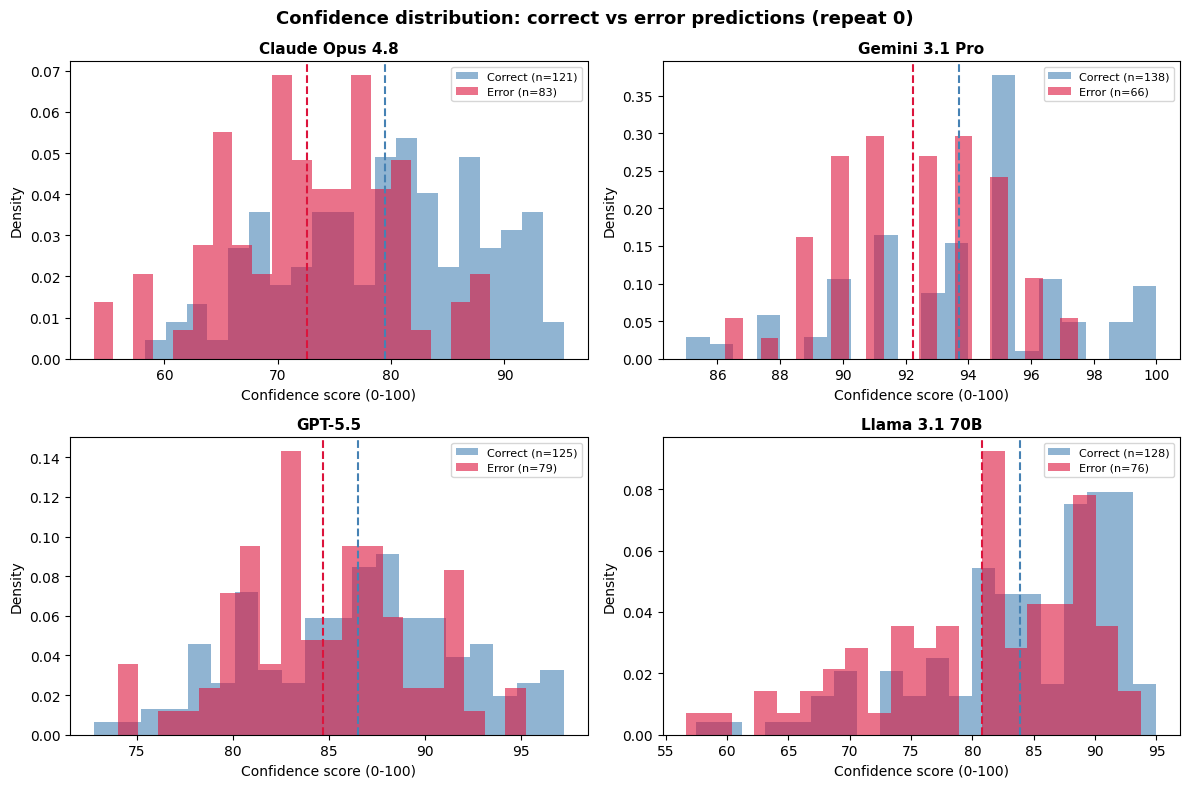

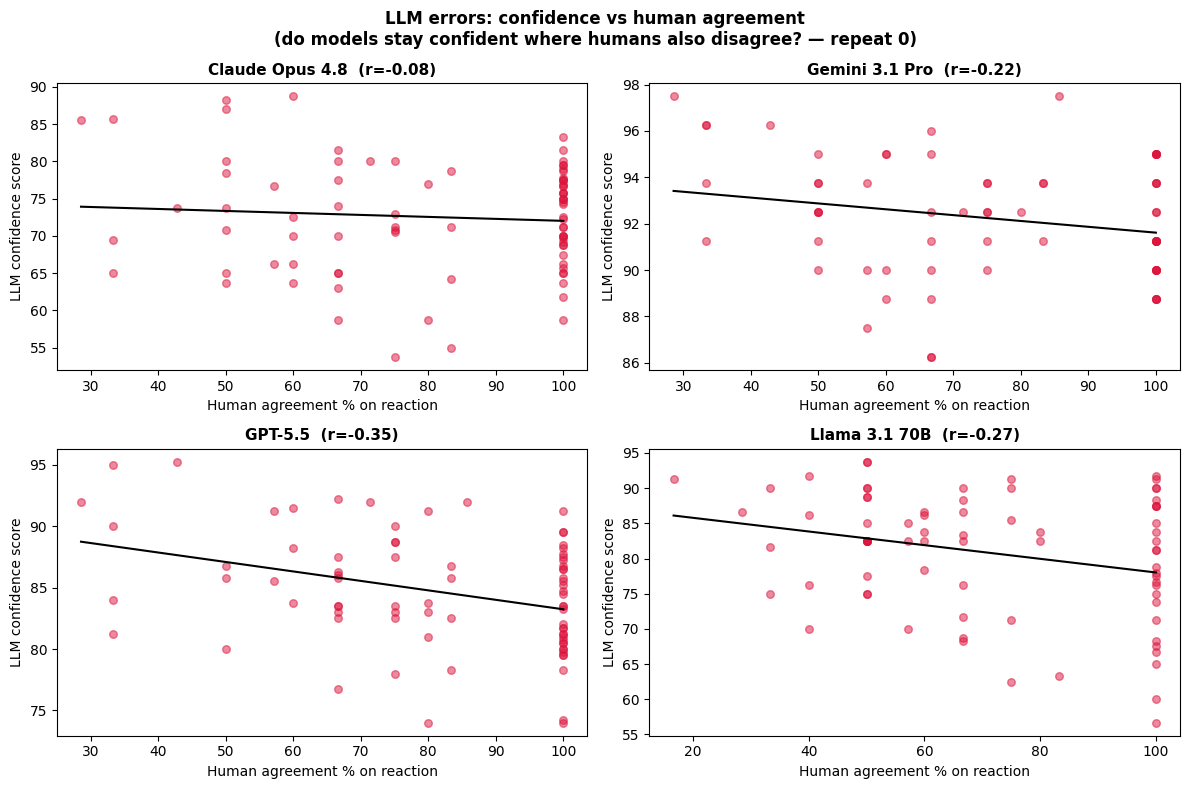


=== Calibration summary per model ===
  Claude Opus 4.8:  mean conf correct=79.4  mean conf error=72.5  gap=6.9
  Gemini 3.1 Pro:  mean conf correct=93.7  mean conf error=92.2  gap=1.5
  GPT-5.5:  mean conf correct=86.5  mean conf error=84.7  gap=1.8
  Llama 3.1 70B:  mean conf correct=83.9  mean conf error=80.8  gap=3.1
Saved confidence_calibration.csv, confidence_calibration_histograms.png, confidence_vs_human_agreement.png

=== Calibration repeat=1 ===


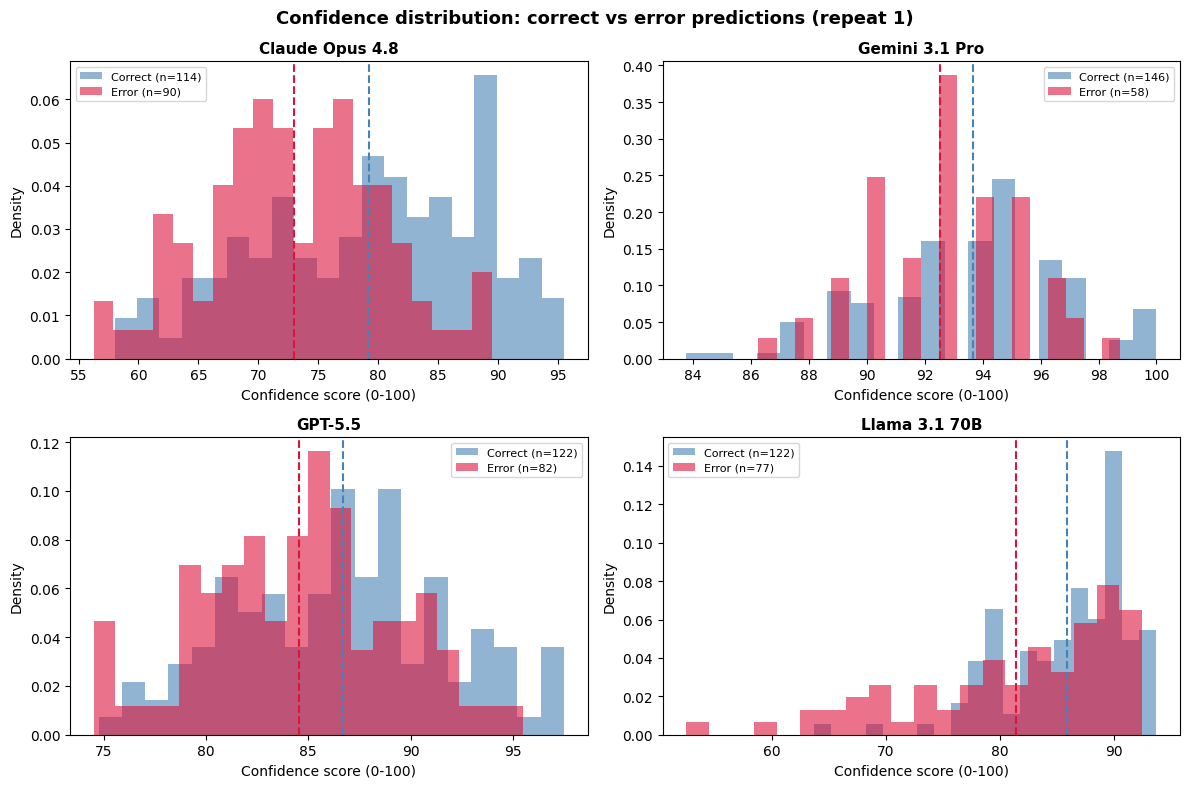

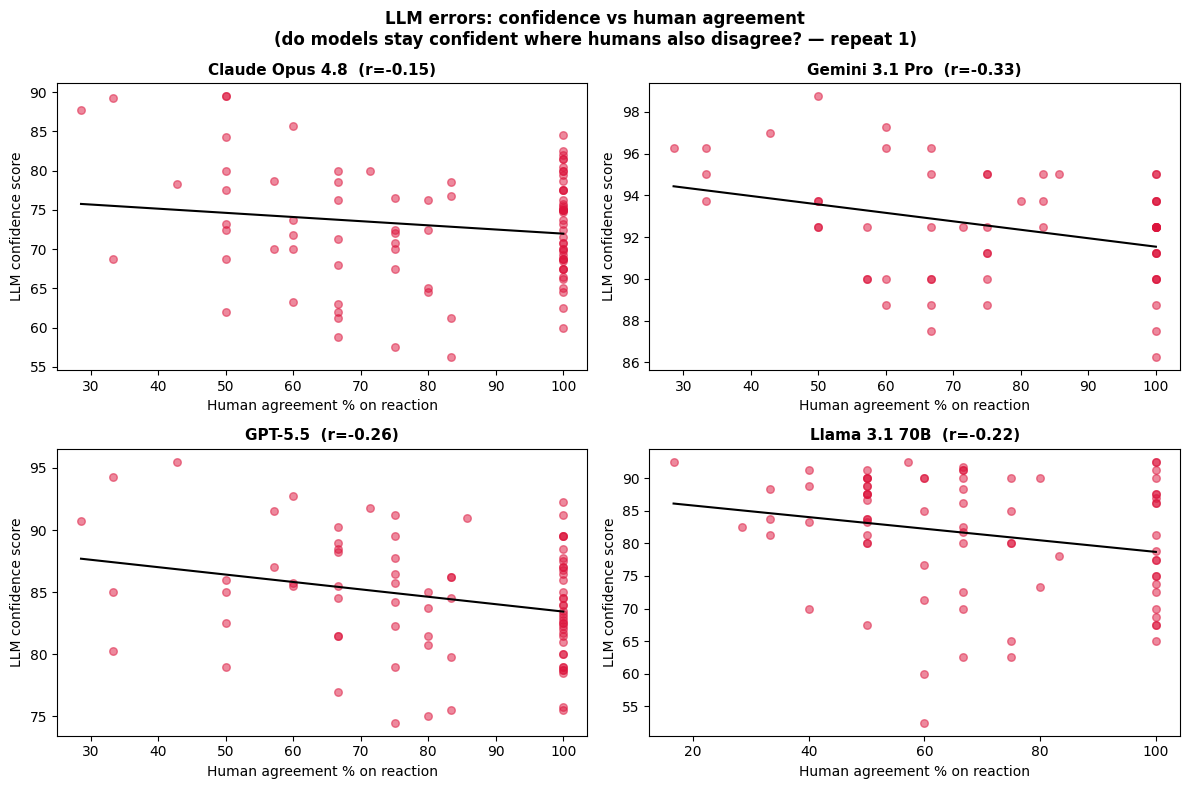


=== Calibration summary per model ===
  Claude Opus 4.8:  mean conf correct=79.2  mean conf error=73.0  gap=6.3
  Gemini 3.1 Pro:  mean conf correct=93.7  mean conf error=92.5  gap=1.2
  GPT-5.5:  mean conf correct=86.7  mean conf error=84.5  gap=2.2
  Llama 3.1 70B:  mean conf correct=85.9  mean conf error=81.4  gap=4.5
Saved confidence_calibration.csv, confidence_calibration_histograms.png, confidence_vs_human_agreement.png

=== Calibration repeat=2 ===


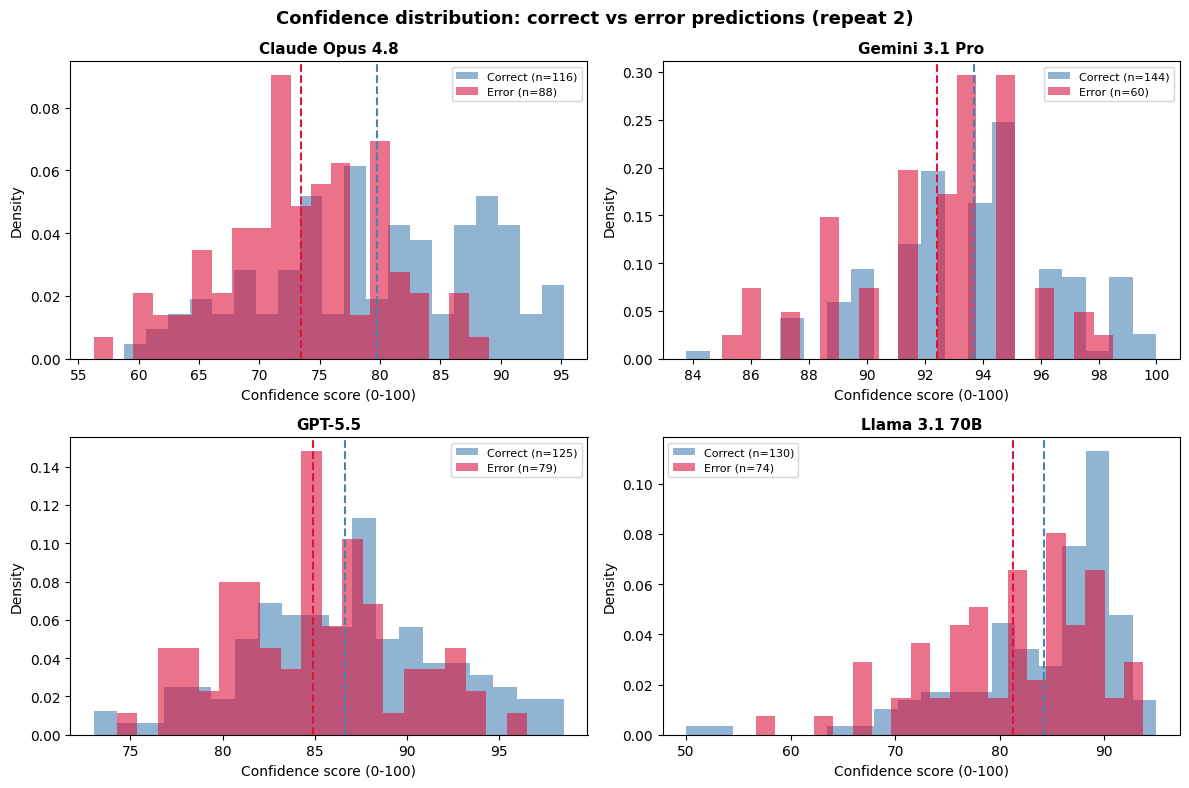

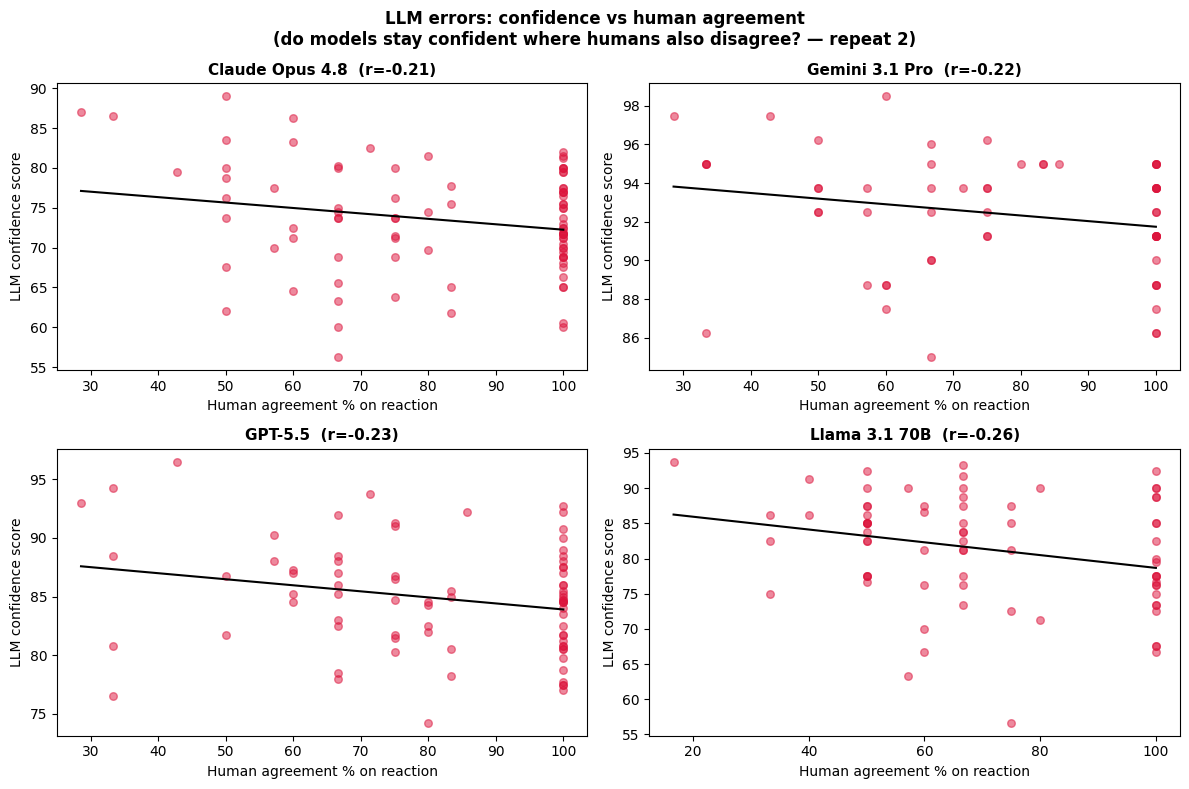


=== Calibration summary per model ===
  Claude Opus 4.8:  mean conf correct=79.7  mean conf error=73.5  gap=6.3
  Gemini 3.1 Pro:  mean conf correct=93.7  mean conf error=92.4  gap=1.3
  GPT-5.5:  mean conf correct=86.6  mean conf error=84.9  gap=1.7
  Llama 3.1 70B:  mean conf correct=84.3  mean conf error=81.3  gap=2.9
Saved confidence_calibration.csv, confidence_calibration_histograms.png, confidence_vs_human_agreement.png

=== Calibration repeat=3 ===


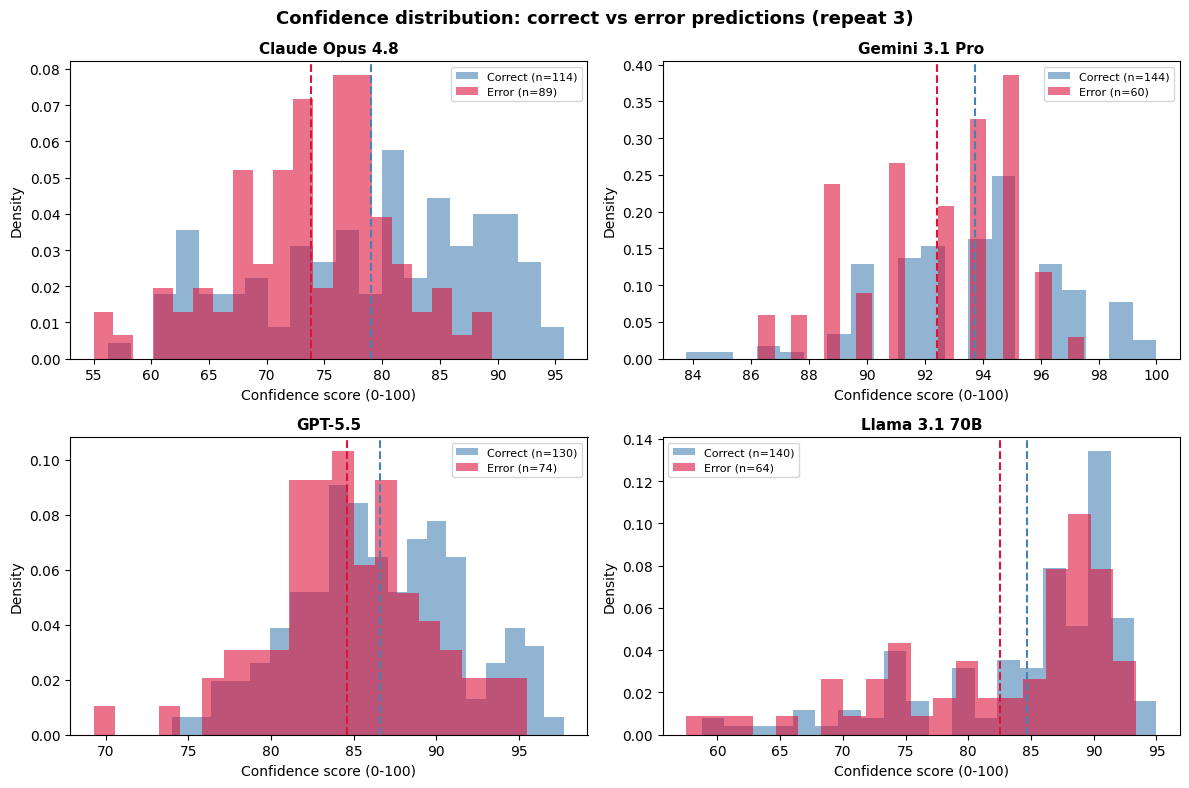

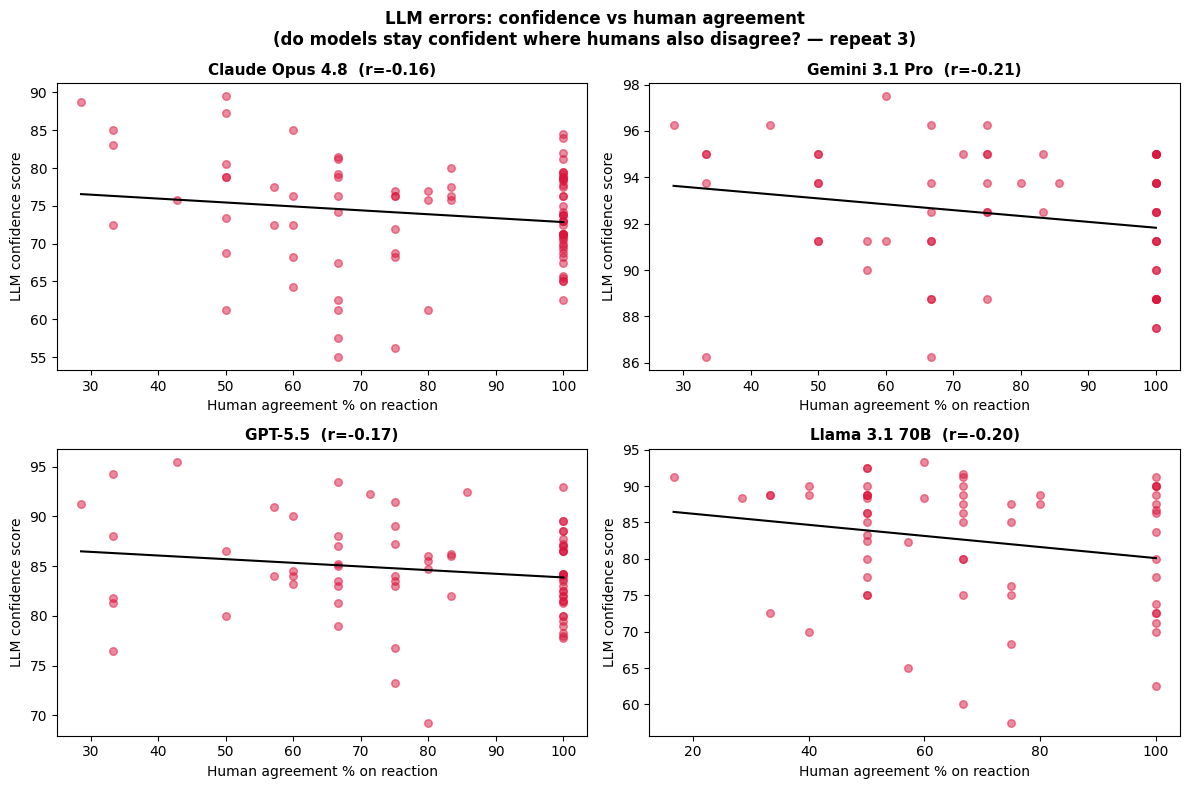


=== Calibration summary per model ===
  Claude Opus 4.8:  mean conf correct=79.0  mean conf error=73.8  gap=5.2
  Gemini 3.1 Pro:  mean conf correct=93.7  mean conf error=92.4  gap=1.3
  GPT-5.5:  mean conf correct=86.6  mean conf error=84.6  gap=2.0
  Llama 3.1 70B:  mean conf correct=84.7  mean conf error=82.5  gap=2.1
Saved confidence_calibration.csv, confidence_calibration_histograms.png, confidence_vs_human_agreement.png


In [18]:
# ── Confidence calibration analysis ──────────────────────────────────────────
for REPEAT_FOR_CALIB in range(4):
    print(f"\n=== Calibration repeat={REPEAT_FOR_CALIB} ===")
    os.makedirs(f"repeat_{REPEAT_FOR_CALIB}", exist_ok=True)

    def human_agreement_pct_for_rxn(rxn_hash, human_df, group_analyzer):
        grp = human_df[human_df["reaction_hash"] == rxn_hash]
        if grp.empty:
            return float("nan")
        res = group_analyzer.get_group_consensus(
            grp, "source_file", "local_feedback", "local_feedback_text"
        )
        return res["agreement_pct"]

    h_agree = {h: human_agreement_pct_for_rxn(h, human_df, group_analyzer_rxn) for h in human_labels}

    llm_r0 = llm_df[llm_df["repeat"] == REPEAT_FOR_CALIB]

    calib_rows = []
    for llm in LLM_IDENTIFIERS:
        sub = llm_r0[llm_r0["source_file"] == llm]
        for rxn_hash, grp in sub.groupby("reaction_hash"):
            if rxn_hash not in human_labels:
                continue
            res = group_analyzer_rxn.get_group_consensus(
                grp, "source_file", "local_feedback", "local_feedback_text"
            )
            sent = res["dominant_sentiment"]
            if sent not in ("Positive", "Negative"):
                continue
            pred    = 1 if sent == "Positive" else 0
            correct = int(pred == human_labels[rxn_hash])
            conf    = grp["confidence"].dropna().mean()
            calib_rows.append({
                "llm": llm,
                "reaction_hash": rxn_hash,
                "confidence": conf,
                "correct": correct,
                "human_agreement_pct": h_agree.get(rxn_hash, float("nan")),
            })

    calib_df = pd.DataFrame(calib_rows)
    calib_df.to_csv(f"repeat_{REPEAT_FOR_CALIB}/confidence_calibration.csv", index=False)

    # ── Confidence distribution: correct vs error per model ─────────────────────
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=False)
    for ax, llm in zip(axes.flat, LLM_IDENTIFIERS):
        sub     = calib_df[calib_df["llm"] == llm].dropna(subset=["confidence"])
        correct = sub[sub["correct"] == 1]["confidence"]
        errors  = sub[sub["correct"] == 0]["confidence"]
        ax.hist(correct, bins=20, alpha=0.6, color="steelblue",
                label=f"Correct (n={len(correct)})", density=True)
        ax.hist(errors,  bins=20, alpha=0.6, color="crimson",
                label=f"Error (n={len(errors)})",   density=True)
        ax.set_title(llm, fontsize=11, fontweight="bold")
        ax.set_xlabel("Confidence score (0-100)")
        ax.set_ylabel("Density")
        if len(correct):
            ax.axvline(correct.mean(), color="steelblue", ls="--", lw=1.5)
        if len(errors):
            ax.axvline(errors.mean(),  color="crimson",   ls="--", lw=1.5)
        ax.legend(fontsize=8)
    plt.suptitle(f"Confidence distribution: correct vs error predictions (repeat {REPEAT_FOR_CALIB})",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"repeat_{REPEAT_FOR_CALIB}/confidence_calibration_histograms.png", dpi=200, bbox_inches="tight")
    plt.show()

    # ── Confidence vs human agreement (errors only) ──────────────────────────────
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    for ax, llm in zip(axes.flat, LLM_IDENTIFIERS):
        sub = calib_df[(calib_df["llm"] == llm) & (calib_df["correct"] == 0)].dropna(
            subset=["confidence", "human_agreement_pct"]
        )
        if sub.empty:
            ax.set_title(f"{llm} (no errors)")
            continue
        ax.scatter(sub["human_agreement_pct"], sub["confidence"],
                   alpha=0.5, s=30, color="crimson")
        z  = np.polyfit(sub["human_agreement_pct"], sub["confidence"], 1)
        xs = np.linspace(sub["human_agreement_pct"].min(), sub["human_agreement_pct"].max(), 50)
        ax.plot(xs, np.poly1d(z)(xs), color="black", lw=1.5)
        corr = sub[["human_agreement_pct", "confidence"]].corr().iloc[0, 1]
        ax.set_title(f"{llm}  (r={corr:.2f})", fontsize=11, fontweight="bold")
        ax.set_xlabel("Human agreement % on reaction")
        ax.set_ylabel("LLM confidence score")
    plt.suptitle("LLM errors: confidence vs human agreement\n"
                 f"(do models stay confident where humans also disagree? — repeat {REPEAT_FOR_CALIB})",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"repeat_{REPEAT_FOR_CALIB}/confidence_vs_human_agreement.png", dpi=200, bbox_inches="tight")
    plt.show()

    print("\n=== Calibration summary per model ===")
    for llm in LLM_IDENTIFIERS:
        sub = calib_df[calib_df["llm"] == llm].dropna(subset=["confidence"])
        c = sub[sub["correct"] == 1]["confidence"]
        e = sub[sub["correct"] == 0]["confidence"]
        if len(c) and len(e):
            print(f"  {llm}:  mean conf correct={c.mean():.1f}  "
                  f"mean conf error={e.mean():.1f}  gap={c.mean() - e.mean():.1f}")
    print("Saved confidence_calibration.csv, confidence_calibration_histograms.png, "
          "confidence_vs_human_agreement.png")


## Confidence Calibration — All Repeats

Two complementary views using all 4 repeats (not just repeat 0):

**Option A — Per-repeat majority vote (4 points per reaction per model)**
Each point = one repeat's consensus prediction for one reaction.
Confidence = mean of the 4 reruns' confidence scores within that repeat.
Methodologically consistent with the MCC analysis.

**Option B — Individual reruns (up to 16 points per reaction per model)**
Each point = one single rerun's prediction and confidence score.
Shows raw within-reaction variance; points within the same reaction are correlated.


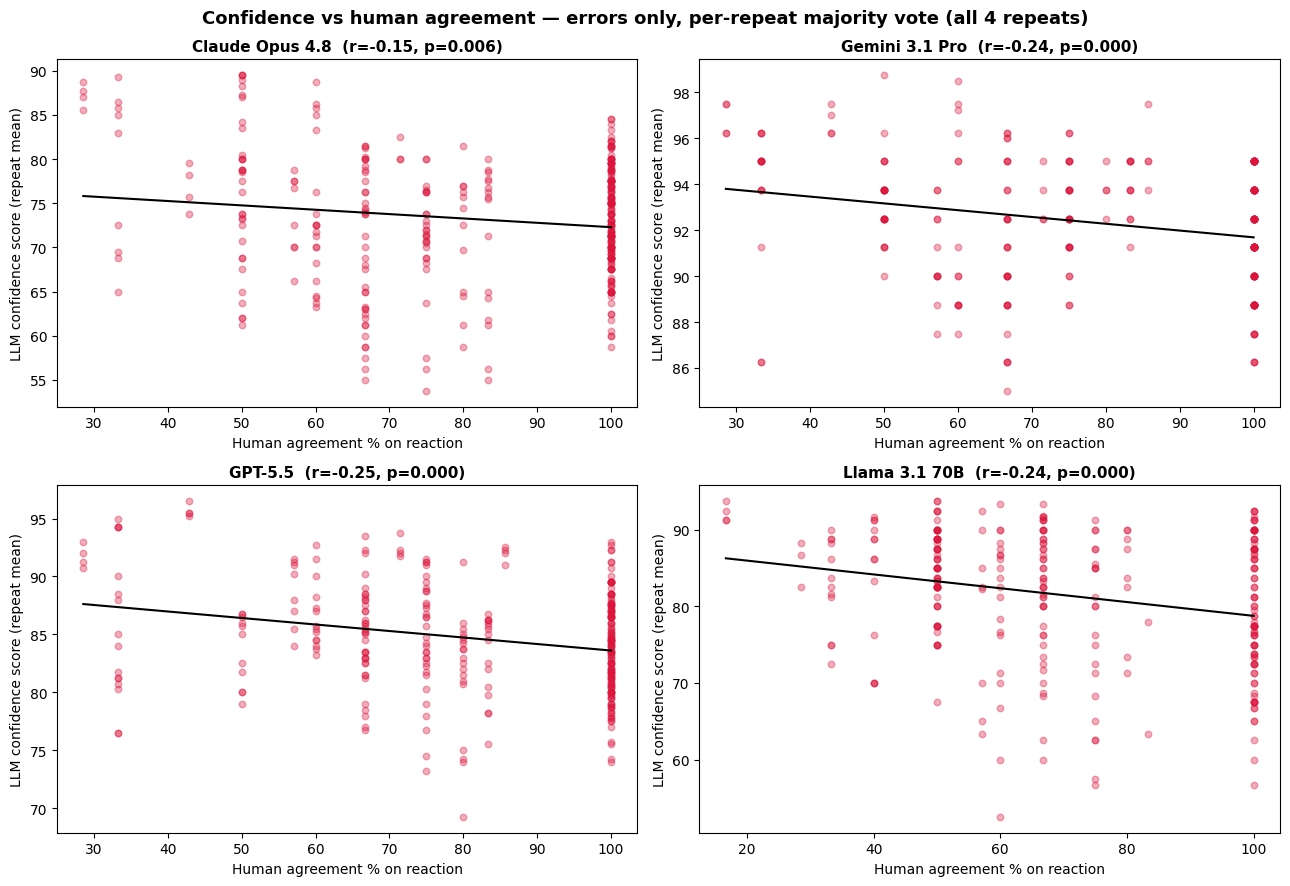

Saved calibration_all_repeats_option_A.png / .csv


In [4]:
# ── Option A: per-repeat majority vote, all 4 repeats ────────────────────────
# Each point = one repeat's consensus for one reaction (4× more points than before)
# Confidence = mean confidence of the 4 reruns within that repeat
# Methodologically identical to the MCC analysis unit

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
os.makedirs("results", exist_ok=True)

CSV = "expert_feedback_combined_new_llms.csv"
LLM_IDENTIFIERS = ["Claude Opus 4.8", "Gemini 3.1 Pro", "GPT-5.5", "Llama 3.1 70B"]
df = pd.read_csv(CSV)
human_mask = ~df["source_file"].isin(LLM_IDENTIFIERS)
human_df   = df[human_mask & df["local_feedback"].notna() & df["reaction_hash"].notna()].copy()
llm_df     = df[~human_mask & (df["feedback_type"] == "reaction")].copy()

# Human ground truth + human_agreement_pct
human_labels = {}
h_agree = {}
ga = GroupConsensusAnalyzer("reaction_hash")
for rxn_hash, grp in human_df.groupby("reaction_hash"):
    res = ga.get_group_consensus(grp, "source_file", "local_feedback", "local_feedback_text")
    sent = res["dominant_sentiment"]
    if sent in ("Positive", "Negative"):
        human_labels[rxn_hash] = 1 if sent == "Positive" else 0
        h_agree[rxn_hash] = res["agreement_pct"]

repeats = sorted(llm_df["repeat"].dropna().unique().astype(int))

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
all_rows_A = []
for ax, llm in zip(axes.flat, LLM_IDENTIFIERS):
    rows = []
    for r in repeats:
        sub = llm_df[(llm_df["source_file"] == llm) & (llm_df["repeat"] == r)]
        for rxn_hash, grp in sub.groupby("reaction_hash"):
            if rxn_hash not in human_labels:
                continue
            res = ga.get_group_consensus(grp, "source_file", "local_feedback", "local_feedback_text")
            sent = res["dominant_sentiment"]
            if sent not in ("Positive", "Negative"):
                continue
            pred    = 1 if sent == "Positive" else 0
            correct = int(pred == human_labels[rxn_hash])
            conf    = grp["confidence"].dropna().mean()
            rows.append({"repeat": r, "rxn_hash": rxn_hash, "confidence": conf,
                         "correct": correct,
                         "human_agreement_pct": h_agree.get(rxn_hash, np.nan)})

    rdf = pd.DataFrame(rows)
    all_rows_A.extend([{**row, "llm": llm} for row in rows])
    errors = rdf[rdf["correct"] == 0].dropna(subset=["confidence", "human_agreement_pct"])

    if errors.empty:
        ax.set_title(f"{llm} (no errors)")
        continue

    ax.scatter(errors["human_agreement_pct"], errors["confidence"],
               alpha=0.35, s=22, color="crimson")
    slope, intercept, r, p, _ = stats.linregress(
        errors["human_agreement_pct"], errors["confidence"])
    xs = np.linspace(errors["human_agreement_pct"].min(),
                     errors["human_agreement_pct"].max(), 50)
    ax.plot(xs, intercept + slope * xs, color="black", lw=1.5)
    ax.set_title(f"{llm}  (r={r:.2f}, p={p:.3f})", fontsize=11, fontweight="bold")
    ax.set_xlabel("Human agreement % on reaction")
    ax.set_ylabel("LLM confidence score (repeat mean)")

plt.suptitle("Confidence vs human agreement — errors only, per-repeat majority vote (all 4 repeats)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("results/calibration_all_repeats_option_A.png", dpi=200, bbox_inches="tight")
plt.show()

pd.DataFrame(all_rows_A).to_csv("results/calibration_all_repeats_option_A.csv", index=False)
print("Saved calibration_all_repeats_option_A.png / .csv")


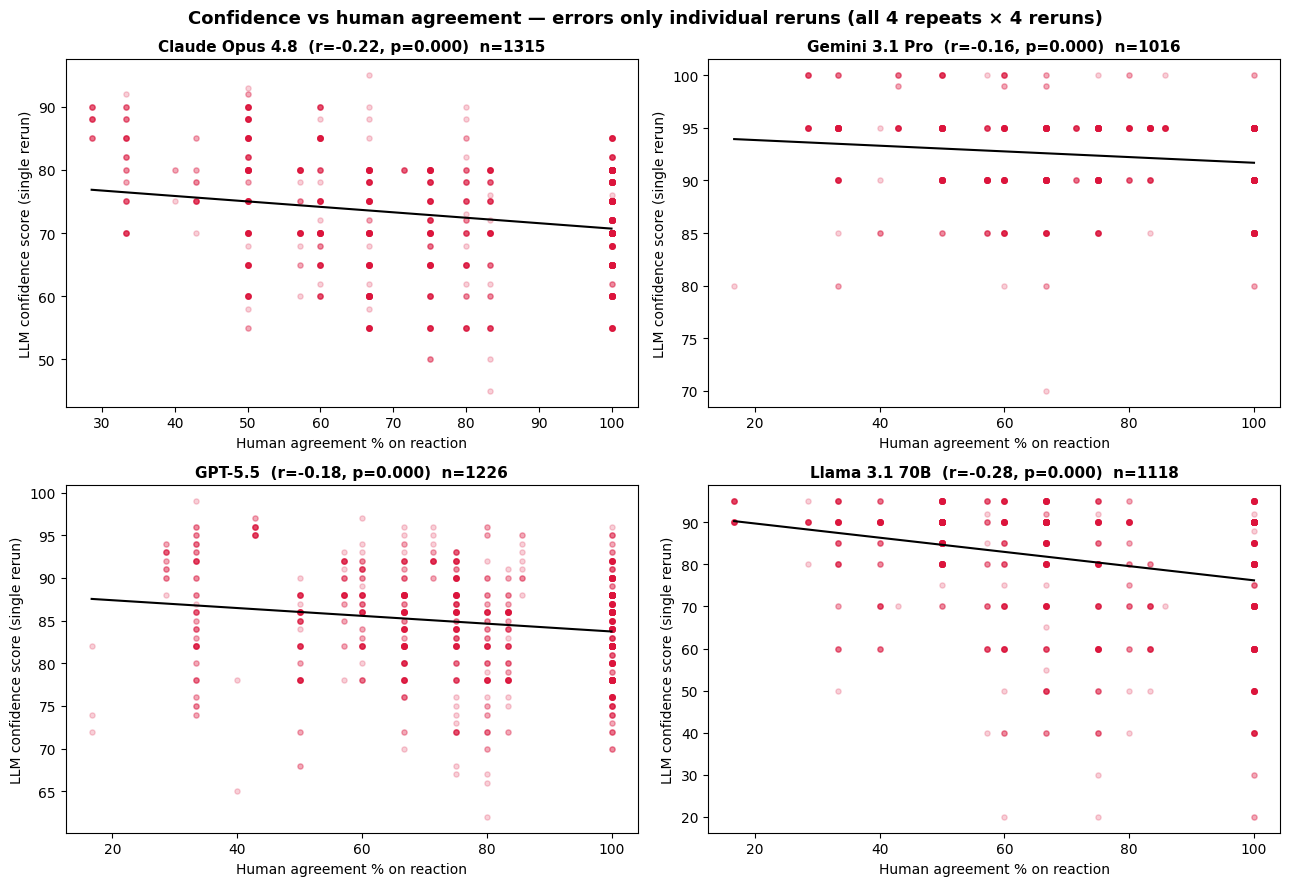

Saved calibration_all_repeats_option_B.png / .csv


In [5]:
# ── Option B: individual reruns, all 4 repeats ────────────────────────────────
# Each point = one single rerun's prediction + confidence (up to 16 per reaction)
# Shows full within-reaction variance; note points within same reaction are correlated

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
all_rows_B = []
for ax, llm in zip(axes.flat, LLM_IDENTIFIERS):
    rows = []
    sub_llm = llm_df[llm_df["source_file"] == llm]
    for rxn_hash, grp in sub_llm.groupby("reaction_hash"):
        if rxn_hash not in human_labels:
            continue
        # Each individual row = one rerun
        for _, row in grp.iterrows():
            cat = row["local_feedback"]
            if not isinstance(cat, str):
                continue
            sent = CategoryMappings.REACTIONS["sentiment"].get(cat)
            if sent not in ("Positive", "Negative"):
                continue
            pred    = 1 if sent == "Positive" else 0
            correct = int(pred == human_labels[rxn_hash])
            rows.append({"repeat": row["repeat"], "iteration": row["iteration"],
                         "rxn_hash": rxn_hash,
                         "confidence": row["confidence"],
                         "correct": correct,
                         "human_agreement_pct": h_agree.get(rxn_hash, np.nan)})

    rdf = pd.DataFrame(rows)
    all_rows_B.extend([{**r, "llm": llm} for r in rows])
    errors = rdf[rdf["correct"] == 0].dropna(subset=["confidence", "human_agreement_pct"])

    if errors.empty:
        ax.set_title(f"{llm} (no errors)")
        continue

    ax.scatter(errors["human_agreement_pct"], errors["confidence"],
               alpha=0.20, s=14, color="crimson")
    slope, intercept, r_val, p, _ = stats.linregress(
        errors["human_agreement_pct"], errors["confidence"])
    xs = np.linspace(errors["human_agreement_pct"].min(),
                     errors["human_agreement_pct"].max(), 50)
    ax.plot(xs, intercept + slope * xs, color="black", lw=1.5)
    ax.set_title(f"{llm}  (r={r_val:.2f}, p={p:.3f})  n={len(errors)}",
                 fontsize=11, fontweight="bold")
    ax.set_xlabel("Human agreement % on reaction")
    ax.set_ylabel("LLM confidence score (single rerun)")

plt.suptitle("Confidence vs human agreement — errors only individual reruns (all 4 repeats × 4 reruns)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("results/calibration_all_repeats_option_B.png", dpi=200, bbox_inches="tight")
plt.show()

pd.DataFrame(all_rows_B).to_csv("results/calibration_all_repeats_option_B.csv", index=False)
print("Saved calibration_all_repeats_option_B.png / .csv")


## Confidence Score Distributions — All Repeats × Reruns

Violin plots of raw individual confidence scores (every single rerun prediction,
all 4 repeats × 4 reruns) split by correct vs error.
Shows the full distribution shape rather than summary statistics.


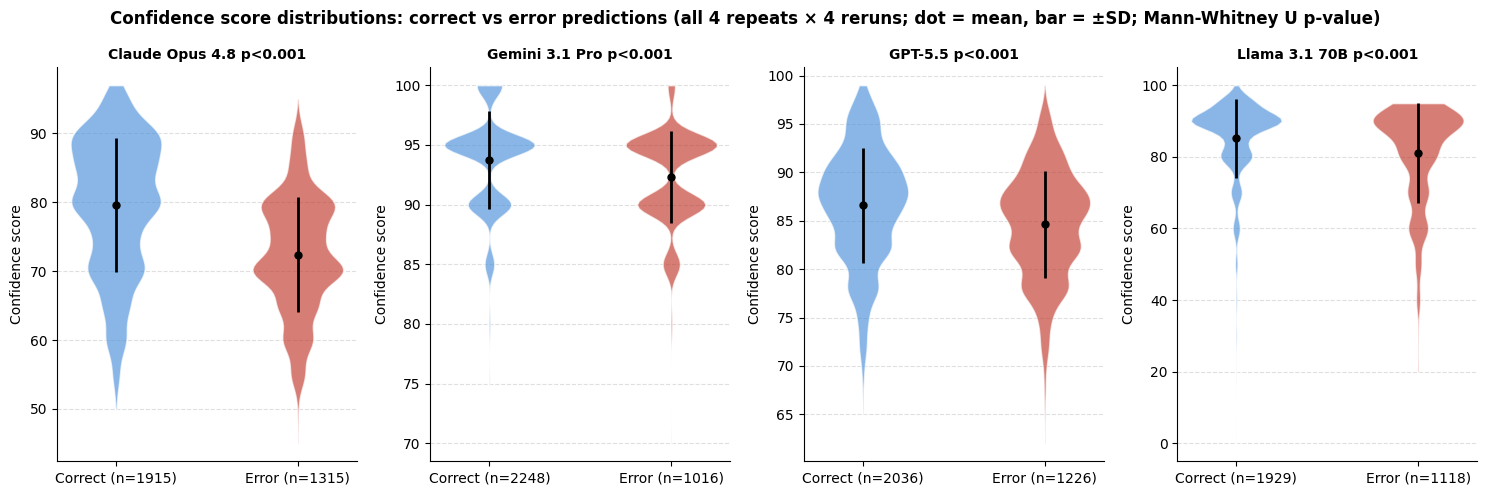


=== Confidence distribution summary (all repeats × reruns) ===
  Claude Opus 4.8       correct: 79.6±9.8  error: 72.4±8.4  Mann-Whitney p=0.0000
  Gemini 3.1 Pro        correct: 93.8±4.1  error: 92.3±3.8  Mann-Whitney p=0.0000
  GPT-5.5               correct: 86.6±5.9  error: 84.6±5.6  Mann-Whitney p=0.0000
  Llama 3.1 70B         correct: 85.1±11.1  error: 81.0±14.0  Mann-Whitney p=0.0000
Saved results/confidence_distributions_all_repeats.png


In [9]:
# ── Confidence score distributions: all repeats × all reruns ─────────────────
# Each observation = one rerun's raw confidence score
# Correct = rerun prediction matches human ground truth label
# Error   = rerun prediction disagrees with human ground truth label

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Build per-rerun correctness using individual rerun labels (not consensus)
conf_data = {llm: {"correct": [], "error": []} for llm in LLM_IDENTIFIERS}

for llm in LLM_IDENTIFIERS:
    sub_llm = llm_df[llm_df["source_file"] == llm]
    for rxn_hash, grp in sub_llm.groupby("reaction_hash"):
        if rxn_hash not in human_labels:
            continue
        for _, row in grp.iterrows():
            cat = row["local_feedback"]
            conf = row["confidence"]
            if not isinstance(cat, str) or pd.isna(conf):
                continue
            sent = CategoryMappings.REACTIONS["sentiment"].get(cat)
            if sent not in ("Positive", "Negative"):
                continue
            pred = 1 if sent == "Positive" else 0
            bucket = "correct" if pred == human_labels[rxn_hash] else "error"
            conf_data[llm][bucket].append(float(conf))

fig, axes = plt.subplots(1, 4, figsize=(15, 5), sharey=False)
for ax, llm in zip(axes, LLM_IDENTIFIERS):
    correct = conf_data[llm]["correct"]
    errors  = conf_data[llm]["error"]

    data = [correct, errors]
    parts = ax.violinplot(data, positions=[0, 1], showmedians=False,
                          showextrema=False)

    colors = ["#4a90d9", "#c0392b"]
    for pc, color in zip(parts["bodies"], colors):
        pc.set_facecolor(color)
        pc.set_alpha(0.65)
        pc.set_edgecolor("white")

    # Overlay mean ± SD
    for pos, vals, color in zip([0, 1], data, colors):
        if vals:
            m, s = np.mean(vals), np.std(vals, ddof=1)
            ax.plot([pos], [m], "o", color="black", ms=5, zorder=5)
            ax.vlines(pos, m - s, m + s, color="black", lw=2, zorder=4)

    # Mann-Whitney U test (non-parametric, no normality assumption)
    if len(correct) > 1 and len(errors) > 1:
        stat, p = stats.mannwhitneyu(correct, errors, alternative="two-sided")
        p_str = f"p={p:.3f}" if p >= 0.001 else "p<0.001"
    else:
        p_str = "n/a"

    ax.set_xticks([0, 1])
    ax.set_xticklabels(
        [f"Correct (n={len(correct)})", f"Error (n={len(errors)})"],
        fontsize=10
    )
    ax.set_title(f"{llm} {p_str}", fontsize=10, fontweight="bold")
    ax.set_ylabel("Confidence score", fontsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.yaxis.grid(True, linestyle="--", alpha=0.4)
    ax.set_axisbelow(True)

plt.suptitle(
    "Confidence score distributions: correct vs error predictions (all 4 repeats × 4 reruns; dot = mean, bar = ±SD; Mann-Whitney U p-value)",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.savefig("results/confidence_distributions_all_repeats.png", dpi=200, bbox_inches="tight")
plt.show()

# Print summary
print("\n=== Confidence distribution summary (all repeats × reruns) ===")
for llm in LLM_IDENTIFIERS:
    c = conf_data[llm]["correct"]
    e = conf_data[llm]["error"]
    if c and e:
        stat, p = stats.mannwhitneyu(c, e, alternative="two-sided")
        print(f"  {llm:20s}  correct: {np.mean(c):.1f}±{np.std(c,ddof=1):.1f}  "
              f"error: {np.mean(e):.1f}±{np.std(e,ddof=1):.1f}  "
              f"Mann-Whitney p={p:.4f}")
print("Saved results/confidence_distributions_all_repeats.png")
